In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [47]:
clean_data_path = "../data/data_clean.csv"
data_df = pd.read_csv(clean_data_path)

In [48]:
len(data_df)

1024

In [137]:
data_df.dtypes


gen                     float64
english_name             object
percent_male            float64
percent_female          float64
height_m                float64
weight_kg               float64
capture_rate            float64
base_egg_steps          float64
hp                      float64
attack                  float64
defense                 float64
sp_attack               float64
sp_defense              float64
speed                   float64
against_normal          float64
against_fire            float64
against_water           float64
against_electric        float64
against_grass           float64
against_ice             float64
against_fighting        float64
against_poison          float64
against_ground          float64
against_flying          float64
against_psychict        float64
against_bug             float64
against_rock            float64
against_ghost           float64
against_dragon          float64
against_dark            float64
against_steel           float64
against_

In [50]:
data_df.describe(include="all")

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
count,1024.000000,1024,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.0000,1024.000000,1024.000000,...,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
unique,NaN,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Bulbasaur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.738281,NaN,46.532100,38.233525,1.211035,66.953906,94.976562,7097.5000,70.152344,77.514648,...,1.092773,2.802734,15.544922,2.372070,3.283203,0.044922,0.030273,0.147461,6.318359,4.623047
std,2.632948,NaN,27.153005,24.713124,1.248642,121.331744,76.129587,6810.6675,26.624286,29.815854,...,0.545856,5.924761,27.267545,0.740691,1.584341,0.207234,0.171422,0.533101,4.949621,5.096766
min,1.000000,NaN,0.000000,0.000000,0.100000,0.100000,3.000000,640.0000,1.000000,5.000000,...,0.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,NaN,50.000000,11.860000,0.500000,8.500000,45.000000,3840.0000,50.000000,55.000000,...,1.000000,0.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,5.000000,NaN,50.200000,49.800000,1.000000,28.000000,60.000000,5120.0000,68.000000,75.000000,...,1.000000,1.000000,6.000000,3.000000,3.000000,0.000000,0.000000,0.000000,5.000000,1.000000
75%,7.000000,NaN,50.200000,50.000000,1.500000,70.000000,140.000000,6400.0000,85.000000,100.000000,...,1.000000,3.000000,15.000000,3.000000,5.000000,0.000000,0.000000,0.000000,10.000000,8.000000


In [51]:
n_primary_classes = data_df["class_primary"].nunique()
n_primary_classes

18

In [52]:
n_secondary_classes = data_df["class_secondary"].nunique()
n_secondary_classes

19


## Univariate z-score outliers ##

What do these outliers look like?
Why are they different from the rest of the data?


Disregard generations for now. Take only numerical features

In [53]:
# Identify outliers;
# ignore "gen" columns and categorical columns

# feature_cols = [col for col in data_df.columns if col not in ["english_name"]]
feature_cols = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]

# let's use z-score method to identify outliers
from scipy import stats
z_scores = np.abs(stats.zscore(data_df[feature_cols], nan_policy="omit"))

z_scores_df = pd.DataFrame(z_scores, columns=feature_cols, index=data_df.index)

outlier_zscore_threshold = 3.0
outliers = (z_scores > outlier_zscore_threshold).any(axis=1)

data_df["outliers_zscore"] = outliers

# sort data by number of outlier features
data_df['num_outlier_features'] = (z_scores > outlier_zscore_threshold).sum(axis=1)
data_df_sorted = data_df.sort_values(by='num_outlier_features', ascending=False)


# List those detected features
data_df["outlier_feature_list"] = (z_scores_df > outlier_zscore_threshold).apply(
    lambda row: list(row.index[row]), axis=1
)


# Count how many outliers were found
num_outliers = outliers.sum()
print(f"Number of outlier samples identified: {num_outliers}")
print(f"Proportion: {num_outliers/len(data_df)}")

Number of outlier samples identified: 31
Proportion: 0.0302734375


In [54]:
#


data_df[["english_name", "outlier_feature_list"]]

,english_name,outlier_feature_list
0,Bulbasaur,[]
1,Ivysaur,[]
2,Venusaur,[]
3,Charmander,[]
4,Charmeleon,[]
...,...,...
1019,Raging Bolt,[]
1020,Iron Boulder,[]
1021,Iron Crown,[]
1022,Terapagos,[]


In [55]:
data_df_sorted.head(20)

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,outliers_zscore,num_outlier_features
212,2.0,Shuckle,50.20,49.80,0.6,20.5,190.0,5120.0,20.0,10.0,...,31.0,3.0,1.0,0.0,0.0,0.0,3,13,True,2
142,1.0,Snorlax,88.14,11.86,2.1,460.0,25.0,10240.0,160.0,110.0,...,98.0,3.0,3.0,0.0,1.0,0.0,4,1,True,1
804,7.0,Stakataka,0.00,0.00,5.5,820.0,30.0,30720.0,61.0,131.0,...,8.0,1.0,1.0,0.0,0.0,1.0,11,11,True,1
241,2.0,Blissey,0.00,100.00,1.5,46.8,30.0,10240.0,255.0,10.0,...,7.0,3.0,5.0,0.0,0.0,0.0,4,1,True,1
670,6.0,Florges,0.00,100.00,1.1,10.0,45.0,5120.0,78.0,65.0,...,6.0,2.0,5.0,0.0,0.0,0.0,8,1,True,1
990,9.0,Iron Hands,0.00,0.00,1.8,380.7,50.0,6400.0,154.0,140.0,...,1.0,1.0,1.0,0.0,0.0,0.0,9,4,True,1
112,1.0,Chansey,0.00,100.00,1.1,34.6,30.0,10240.0,250.0,5.0,...,10.0,3.0,5.0,0.0,0.0,0.0,4,1,True,1
486,4.0,Giratina,0.00,0.00,4.5,750.0,3.0,30720.0,150.0,100.0,...,78.0,3.0,1.0,0.0,0.0,2.0,12,15,True,1
795,7.0,Xurkitree,0.00,0.00,3.8,100.0,45.0,30720.0,83.0,89.0,...,13.0,1.0,1.0,0.0,0.0,1.0,6,1,True,1
798,7.0,Guzzlord,0.00,0.00,5.5,888.0,45.0,30720.0,223.0,101.0,...,5.0,1.0,1.0,0.0,0.0,1.0,15,15,True,1


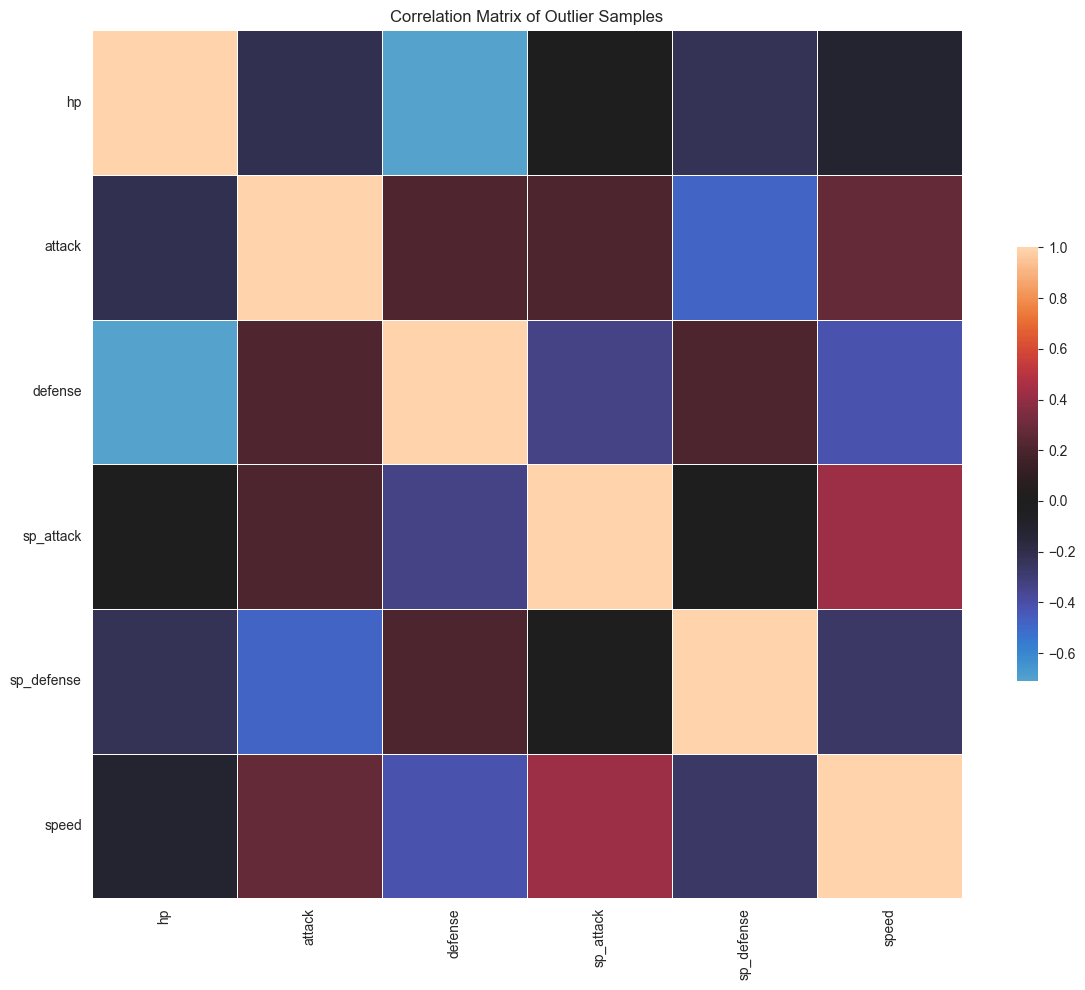

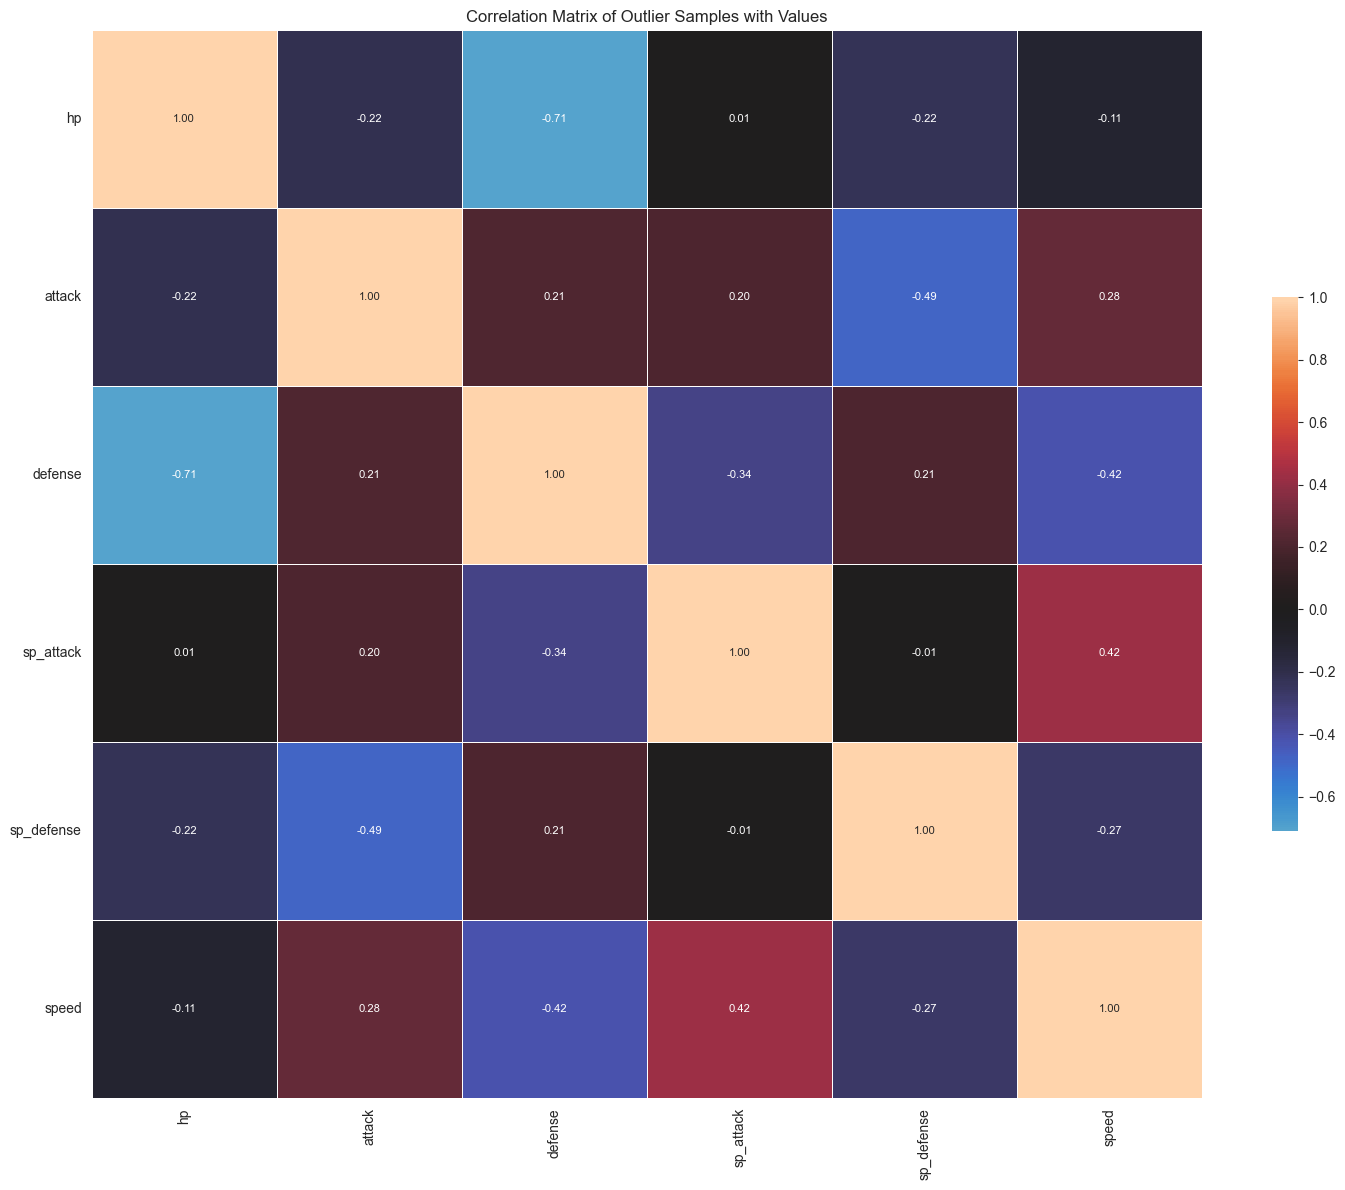

In [56]:
# Correlation heatmap of features for outlier samples
outlier_data = data_df[outliers]
outlier_features = outlier_data[feature_cols]
corr_matrix = outlier_features.corr()
plt.figure(figsize=(12, 10))
sns.color_palette("rocket")
sns.heatmap(corr_matrix, center=0, annot=False, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5})
plt.title("Correlation Matrix of Outlier Samples")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Let's add the actual values into the heatmap
# Make sure to make the figure larger for better readability
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5}, annot_kws={"size": 8})
plt.title("Correlation Matrix of Outlier Samples with Values")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [57]:
# Let's enumerate the most interesting correlations among outlier features
abs_corr = corr_matrix.abs()
pairs = (
    abs_corr.unstack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
)
pairs = pairs[pairs['var1'] != pairs['var2']]
# keep unique pairs (unordered) and sort by absolute correlation
pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted((r['var1'], r['var2']))), axis=1)
top_pairs = pairs.drop_duplicates(subset='pair_key').sort_values('abs_corr', ascending=False)

In [58]:
top_pairs.head(20)

,var1,var2,abs_corr,pair_key
2,hp,defense,0.711611,"(defense, hp)"
10,attack,sp_defense,0.489186,"(attack, sp_defense)"
23,sp_attack,speed,0.421480,"(sp_attack, speed)"
17,defense,speed,0.415044,"(defense, speed)"
15,defense,sp_attack,0.343115,"(defense, sp_attack)"
11,attack,speed,0.277751,"(attack, speed)"
29,sp_defense,speed,0.266017,"(sp_defense, speed)"
4,hp,sp_defense,0.224837,"(hp, sp_defense)"
1,hp,attack,0.215454,"(attack, hp)"
8,attack,defense,0.213645,"(attack, defense)"


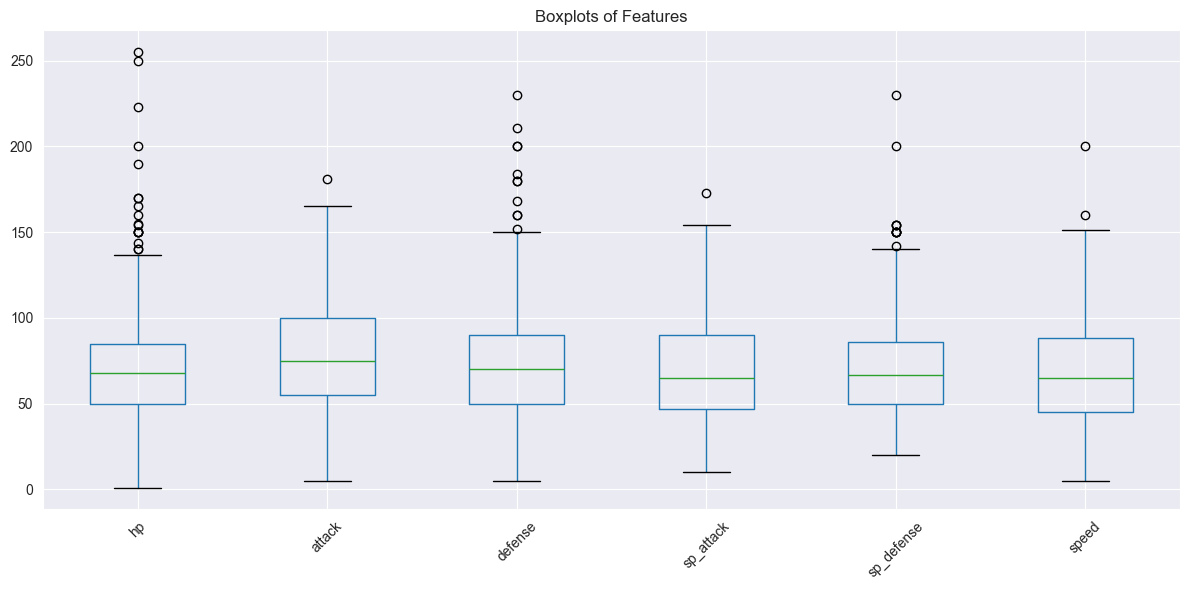

In [59]:
# Boxplots and histograms


plt.figure(figsize=(12, 6))
data_df[feature_cols].boxplot()
plt.title("Boxplots of Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# Histograms of features

# fig, axes = plt.subplots(nrows=len(feature_cols), ncols=1, figsize=(10, 5 * len(feature_cols)))
# for ax, col in zip(axes, feature_cols):
#     sns.histplot(data_df[col], bins=30, kde=True, ax=ax)
#     ax.set_title(f"Histogram of {col}")
# plt.tight_layout()
# plt.show()

In [61]:
# Highlight pokemns with many outlier features in these distributions

threshold = data_df['num_outlier_features'].quantile(0.95)  # top 5% as high outlier count
high_outlier_data = data_df[data_df['num_outlier_features'] >= threshold].sort_values(by='num_outlier_features', ascending=False)

print("Pokemons with high number of outlier features:")
print(f"(Threshold: {threshold} outlier features)")
display(high_outlier_data[['english_name', 'num_outlier_features'] + feature_cols].reset_index(drop=True))

Pokemons with high number of outlier features:
(Threshold: 0.0 outlier features)


,english_name,num_outlier_features,hp,attack,defense,sp_attack,sp_defense,speed
0,Shuckle,2,20.0,10.0,230.0,10.0,230.0,5.0
1,Snorlax,1,160.0,110.0,65.0,65.0,110.0,30.0
2,Stakataka,1,61.0,131.0,211.0,53.0,101.0,13.0
3,Blissey,1,255.0,10.0,10.0,75.0,135.0,55.0
4,Florges,1,78.0,65.0,68.0,112.0,154.0,75.0
...,...,...,...,...,...,...,...,...
1019,Banette,0,64.0,115.0,65.0,83.0,63.0,65.0
1020,Duskull,0,20.0,40.0,90.0,30.0,90.0,25.0
1021,Dusclops,0,40.0,70.0,130.0,60.0,130.0,25.0
1022,Tropius,0,99.0,68.0,83.0,72.0,87.0,51.0


In [62]:
tmp = data_df[data_df['num_outlier_features'] > 0]
tmp[["english_name", "num_outlier_features", "outlier_feature_list"]]

,english_name,num_outlier_features,outlier_feature_list
90,Cloyster,1,[defense]
112,Chansey,1,[hp]
142,Snorlax,1,[hp]
201,Wobbuffet,1,[hp]
207,Steelix,1,[defense]
212,Shuckle,2,"[defense, sp_defense]"
241,Blissey,1,[hp]
248,Lugia,1,[sp_defense]
249,Ho-Oh,1,[sp_defense]
288,Slaking,1,[hp]


In [63]:
# Lets print count plot of top 20 pokemons with highest outlier features by their primary class

# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='class_primary', order=high_outlier_data['class_primary'].value_counts().index)
#
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Primary Class")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
#
# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='gen', order=high_outlier_data['gen'].value_counts().index)
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Generation")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



In [64]:
def scatter_with_outliers(df, x_col, y_col, outlier_mask, annotate=True):
    plt.figure(figsize=(10, 6))
    plt.scatter(df[~outlier_mask][x_col], df[~outlier_mask][y_col], label='Normal Data', alpha=0.4)
    plt.scatter(df[outlier_mask][x_col], df[outlier_mask][y_col], color='red', label='Outliers', alpha=0.7)

    # Annotate outlier points
    if annotate:
        for _, row in df[outlier_mask].iterrows():
            plt.annotate(row['english_name'], (row[x_col], row[y_col]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Scatter Plot of {y_col} vs {x_col}')
    plt.legend()
    plt.grid(True)
    plt.show()

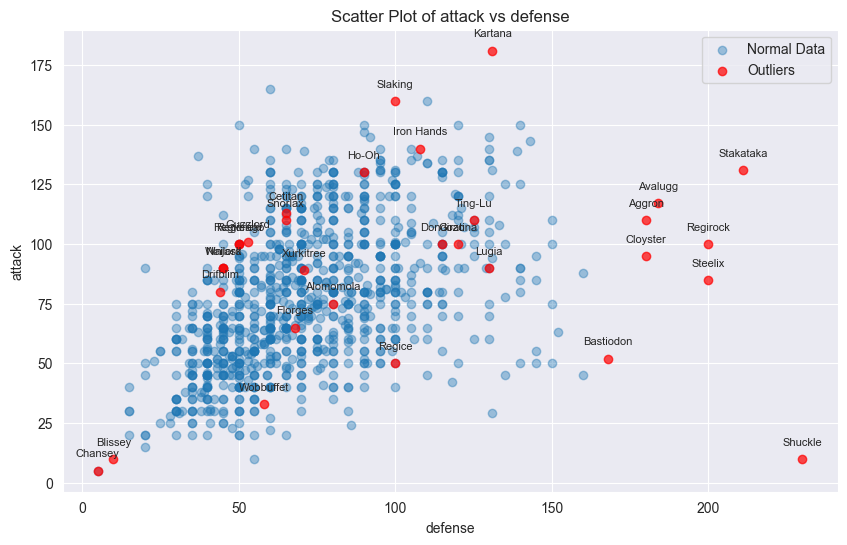

In [65]:
scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=True)
#scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=False)

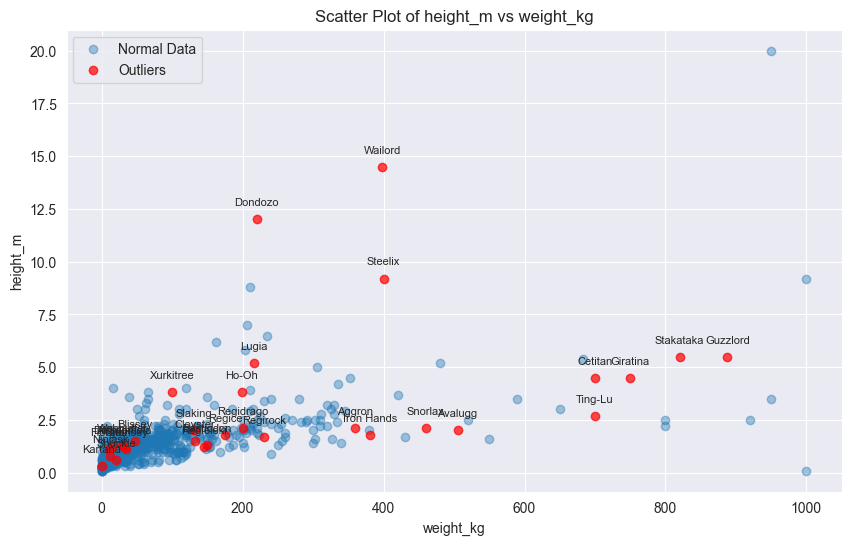

In [66]:
scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=True)
#scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=False)

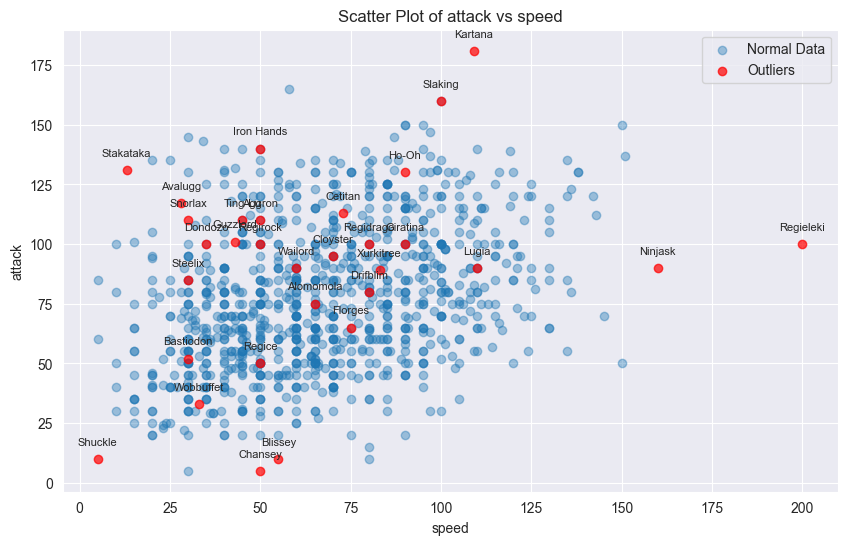

In [67]:
scatter_with_outliers(data_df, 'speed', 'attack', outliers, annotate=True)

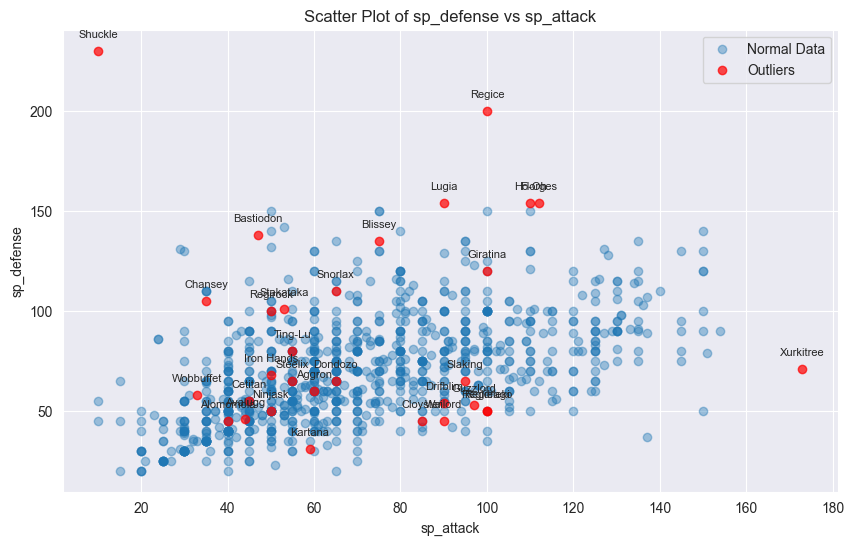

In [68]:
scatter_with_outliers(data_df, 'sp_attack', 'sp_defense', outliers, annotate=True)

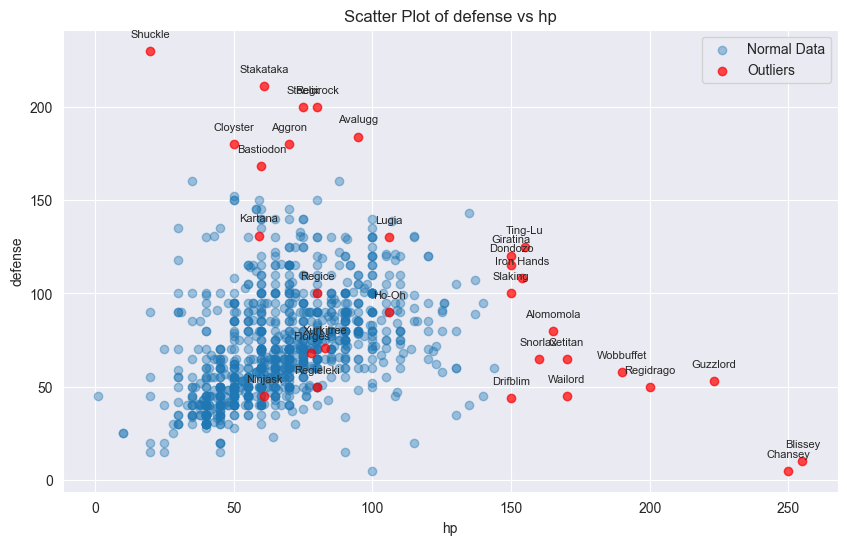

In [69]:
scatter_with_outliers(data_df, 'hp', 'defense', outliers, annotate=True)

In [70]:
# display scatter plots with top correlated feature pairs among outliers

# for _, row in top_pairs.head(10).iterrows():
#     scatter_with_outliers(data_df, row['var1'], row['var2'], outliers, annotate=True)

## Multivariate anomalies ##


In [71]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [145]:
num_cols = [c for c in data_df.select_dtypes(include=[np.number]).columns if c in feature_cols]
print(num_cols)
X = data_df[num_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']


In [73]:
def visualize_score_distribution(score_column, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True)
    plt.title(title)
    plt.xlabel("Score")
    plt.grid(True)
    plt.show()

def plot_decision_function_2d(score_column, title, anomaly_flag_col=None, annotate=True):
    plt.figure(figsize=(9, 7))

    # Sort: anomalies on top
    df_sorted = data_df.sort_values(score_column)

    scatter = plt.scatter(
        df_sorted["pca_vis_1"],
        df_sorted["pca_vis_2"],
        c=df_sorted[score_column],
        cmap="viridis",
        alpha=0.7
    )

    plt.colorbar(scatter, label=score_column)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)

    if anomaly_flag_col is not None:
        anomalies = data_df[data_df[anomaly_flag_col]]

        # Highlight anomalies
        plt.scatter(
            anomalies["pca_vis_1"],
            anomalies["pca_vis_2"],
            color="red",
            s=60,
            edgecolor="black",
            label="Detected Anomaly"
        )

        # Add annotations
        if annotate:
            for _, row in anomalies.iterrows():
                plt.annotate(
                    row["english_name"],
                    (row["pca_vis_1"], row["pca_vis_2"]),
                    fontsize=6,
                    xytext=(3, 3),
                    textcoords="offset points"
                )

        plt.legend()
    plt.show()

def plot_score_with_anomalies(score_column, anomaly_flag_col, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True, color="gray")

    # overlay anomalies
    anomaly_scores = data_df.loc[data_df[anomaly_flag_col], score_column]
    plt.scatter(anomaly_scores, np.zeros_like(anomaly_scores),
                color="red", label="Anomalies", s=40)

    plt.title(title)
    plt.legend()
    plt.show()



### Isolation Forest ###

In [74]:
 # anomaly detection with isolation forest
from sklearn.ensemble import IsolationForest

In [75]:
# contamination estimate based on z-values (341 out of 1024 = 33%)
# contamination_estimate = 0.33
contamination_estimate = 0.03027


In [76]:
# add a column to the original dataframe to keep track of anomalies detected by isolation forests

iso = IsolationForest(n_estimators=100,
                      contamination=contamination_estimate,
                      random_state=42)

iso_pred = iso.fit_predict(X_scaled)
iso_score = iso.decision_function(X_scaled)

data_df["anomaly_if"] = (iso_pred == -1)
data_df["iforest_score"] = iso_score


In [77]:
# Let's see the results

outliers_if_df = data_df[data_df["anomaly_if"] == True]

outliers_if_df

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,outliers_zscore,num_outlier_features,outlier_feature_list,anomaly_if,iforest_score
38,1.0,Jigglypuff,24.90,75.10,0.5,5.5,170.0,2560.0,115.0,45.0,...,0.0,0.0,0.0,4,7,False,0,[],True,-0.011436
62,1.0,Abra,75.49,24.51,0.9,19.5,200.0,5120.0,25.0,20.0,...,0.0,0.0,0.0,10,1,False,0,[],True,-0.003200
112,1.0,Chansey,0.00,100.00,1.1,34.6,30.0,10240.0,250.0,5.0,...,0.0,0.0,0.0,4,1,True,1,[hp],True,-0.120949
128,1.0,Magikarp,50.20,49.80,0.9,10.0,255.0,1280.0,20.0,10.0,...,0.0,0.0,0.0,2,1,False,0,[],True,-0.026767
173,2.0,Igglybuff,24.90,75.10,0.3,1.0,170.0,2560.0,90.0,30.0,...,0.0,0.0,0.0,4,7,False,0,[],True,-0.029714
201,2.0,Wobbuffet,50.20,49.80,1.3,28.5,45.0,5120.0,190.0,33.0,...,0.0,0.0,0.0,10,1,True,1,[hp],True,-0.022505
212,2.0,Shuckle,50.20,49.80,0.6,20.5,190.0,5120.0,20.0,10.0,...,0.0,0.0,0.0,3,13,True,2,"[defense, sp_defense]",True,-0.185133
241,2.0,Blissey,0.00,100.00,1.5,46.8,30.0,10240.0,255.0,10.0,...,0.0,0.0,0.0,4,1,True,1,[hp],True,-0.122563
248,2.0,Lugia,0.00,0.00,5.2,216.0,3.0,30720.0,106.0,90.0,...,0.0,0.0,2.0,10,2,True,1,[sp_defense],True,-0.021384
288,3.0,Slaking,50.00,50.00,2.0,130.5,45.0,3840.0,150.0,160.0,...,0.0,0.0,0.0,4,1,True,1,[hp],True,-0.020956


In [78]:
len(outliers_if_df)

31

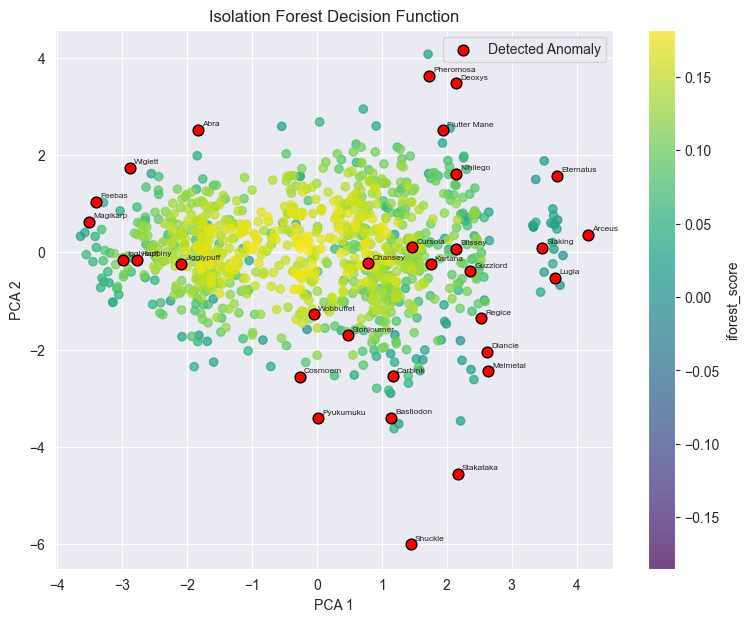

In [85]:
# visualize_score_distribution("iforest_score", "Isolation Forest Score Distribution")
# scatter_with_outliers(data_df, 'weight_kg', 'height_m', data_df["anomaly_if"], annotate=True)
# scatter_with_outliers(data_df, 'hp', 'defense', data_df["anomaly_if"], annotate=True)

plot_decision_function_2d(
    score_column="iforest_score",
    title="Isolation Forest Decision Function",
    anomaly_flag_col="anomaly_if",
    annotate=True
)


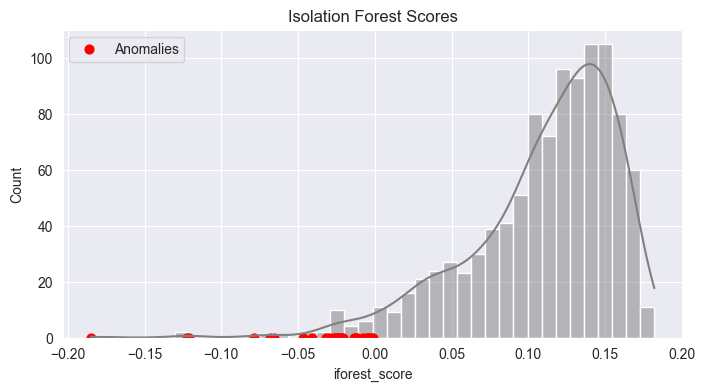

In [86]:
plot_score_with_anomalies("iforest_score", "anomaly_if", "Isolation Forest Scores")

## Local Outlier Factor ##

In [87]:
from sklearn.neighbors import LocalOutlierFactor

In [92]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_estimate,
    novelty=False
)

lof_pred = lof.fit_predict(X_scaled) # -1 = anomaly, 1 = normal
lof_score = lof.negative_outlier_factor_ # more negative = more abnormal

data_df["anomaly_lof"] = (lof_pred == -1)
data_df["lof_score"] = lof_score

In [93]:
len(data_df[data_df["anomaly_lof"] == True])

31

In [138]:
data_df[data_df["anomaly_lof"] == True]


,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,anomaly_pca,pca_vis_1,pca_vis_2,anomaly_lof,lof_score,anomaly_ocsvm,ocsvm_score,anomaly_fired,anomaly_any,anomaly_strong
38,1.0,Jigglypuff,24.90,75.10,0.5,5.5,170.0,2560.0,115.0,45.0,...,False,-2.087343,-0.230204,True,-1.688275,True,-0.000136,3,True,False
62,1.0,Abra,75.49,24.51,0.9,19.5,200.0,5120.0,25.0,20.0,...,False,-1.829497,2.522801,True,-1.963425,False,0.000368,2,True,False
91,1.0,Gastly,50.20,49.80,1.3,0.1,190.0,5120.0,30.0,35.0,...,False,-1.843602,1.987768,True,-1.663732,False,0.162182,1,True,False
94,1.0,Onix,50.20,49.80,8.8,210.0,45.0,6400.0,35.0,45.0,...,False,-0.832056,-1.804446,True,-1.720849,False,0.000034,1,True,False
112,1.0,Chansey,0.00,100.00,1.1,34.6,30.0,10240.0,250.0,5.0,...,True,0.791291,-0.226224,True,-2.474683,True,-0.000051,5,True,True
115,1.0,Horsea,50.20,49.80,0.4,8.0,225.0,5120.0,30.0,40.0,...,False,-2.051697,0.386220,True,-1.877870,False,0.272467,1,True,False
128,1.0,Magikarp,50.20,49.80,0.9,10.0,255.0,1280.0,20.0,10.0,...,False,-3.513650,0.630140,True,-1.847761,True,-0.000126,3,True,False
173,2.0,Igglybuff,24.90,75.10,0.3,1.0,170.0,2560.0,90.0,30.0,...,False,-2.981025,-0.154891,True,-1.762967,False,0.000114,2,True,False
201,2.0,Wobbuffet,50.20,49.80,1.3,28.5,45.0,5120.0,190.0,33.0,...,True,-0.041958,-1.271992,True,-1.574418,False,0.000145,4,True,True
212,2.0,Shuckle,50.20,49.80,0.6,20.5,190.0,5120.0,20.0,10.0,...,True,1.447084,-6.004529,True,-2.660390,True,-0.549887,5,True,True


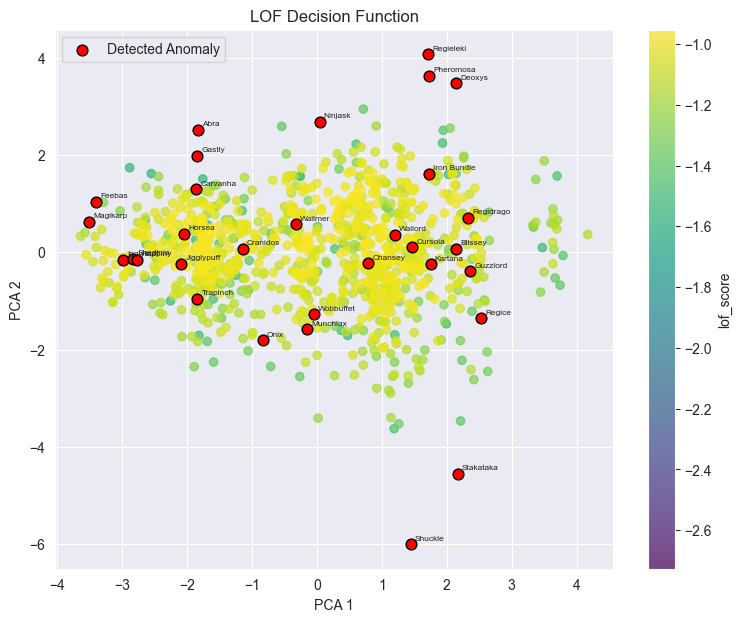

In [94]:

plot_decision_function_2d(
    score_column="lof_score",
    title="LOF Decision Function",
    anomaly_flag_col="anomaly_lof",
    annotate=True
)


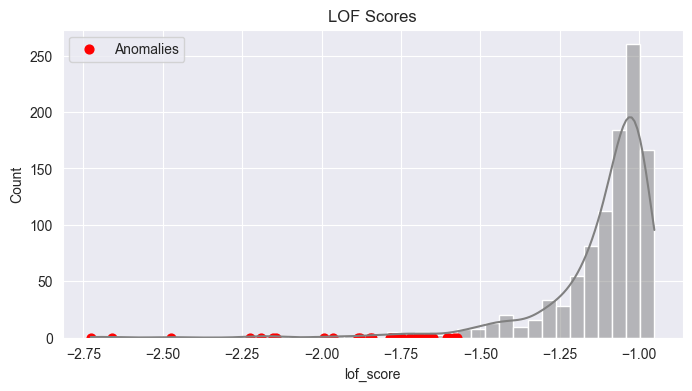

In [95]:
plot_score_with_anomalies("lof_score", "anomaly_lof", "LOF Scores")

## PCA anomaly score ##

In [80]:
from sklearn.decomposition import PCA

In [97]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

pca_dist = np.linalg.norm(X_pca, axis=1)

pca_contamination = contamination_estimate
# pca_contamination = 0.05
pca_threshold = np.quantile(pca_dist, 1 - pca_contamination)
print(pca_threshold)

data_df["pca_dist"] = pca_dist
data_df["anomaly_pca"] = pca_dist > pca_threshold

4.0596495698114285


In [96]:
# len(data_df["anomaly_pca"] == True)
print(len(data_df[data_df["anomaly_pca"] == True]))
print(len(data_df[data_df["anomaly_pca"] == False]))


31
993


In [140]:
data_df[data_df["anomaly_pca"] == True]

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,anomaly_pca,pca_vis_1,pca_vis_2,anomaly_lof,lof_score,anomaly_ocsvm,ocsvm_score,anomaly_fired,anomaly_any,anomaly_strong
112,1.0,Chansey,0.0,100.0,1.1,34.6,30.0,10240.0,250.0,5.0,...,True,0.791291,-0.226224,True,-2.474683,True,-0.000051,5,True,True
201,2.0,Wobbuffet,50.2,49.8,1.3,28.5,45.0,5120.0,190.0,33.0,...,True,-0.041958,-1.271992,True,-1.574418,False,0.000145,4,True,True
207,2.0,Steelix,50.2,49.8,9.2,400.0,25.0,6400.0,75.0,85.0,...,True,1.188273,-3.627400,False,-1.444852,False,0.000012,2,True,False
212,2.0,Shuckle,50.2,49.8,0.6,20.5,190.0,5120.0,20.0,10.0,...,True,1.447084,-6.004529,True,-2.660390,True,-0.549887,5,True,True
241,2.0,Blissey,0.0,100.0,1.5,46.8,30.0,10240.0,255.0,10.0,...,True,2.143858,0.076341,True,-2.726833,True,-0.013743,5,True,True
248,2.0,Lugia,0.0,0.0,5.2,216.0,3.0,30720.0,106.0,90.0,...,True,3.669527,-0.528420,False,-1.386637,True,-0.000049,4,True,True
288,3.0,Slaking,50.0,50.0,2.0,130.5,45.0,3840.0,150.0,160.0,...,True,3.471529,0.098714,False,-1.532010,False,0.000449,3,True,False
376,3.0,Regirock,0.0,0.0,1.7,230.0,3.0,20480.0,80.0,100.0,...,True,2.212783,-3.468533,False,-1.414283,False,0.000151,2,True,False
377,3.0,Regice,0.0,0.0,1.8,175.0,3.0,20480.0,80.0,50.0,...,True,2.534298,-1.354618,True,-1.771801,True,-0.077333,5,True,True
381,3.0,Kyogre,0.0,0.0,4.5,352.0,3.0,30720.0,100.0,100.0,...,True,3.604184,0.604230,False,-1.238728,False,0.167938,1,True,False


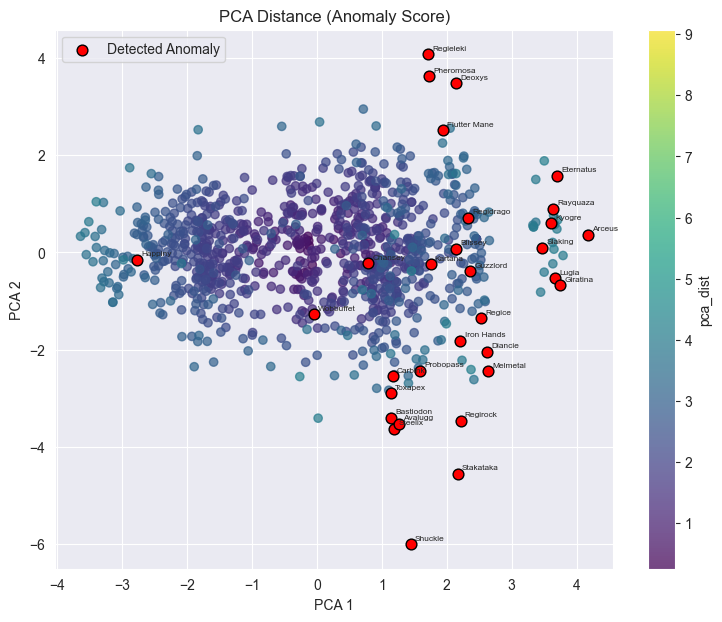

In [98]:
plot_decision_function_2d(
    score_column="pca_dist",
    title="PCA Distance (Anomaly Score)",
    anomaly_flag_col="anomaly_pca"
)


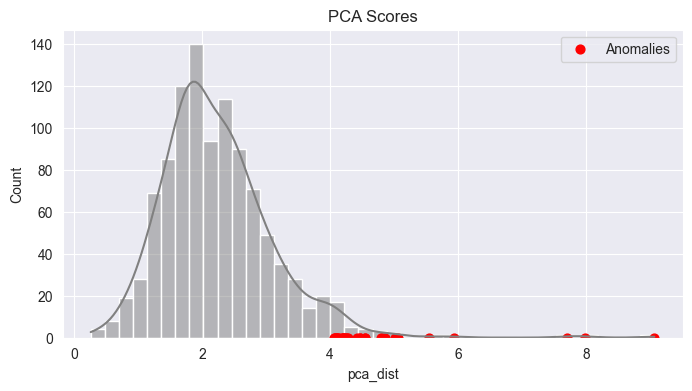

In [99]:
plot_score_with_anomalies("pca_dist", "anomaly_pca", "PCA Scores")

## One Class SVM ##

In [100]:
from sklearn.svm import OneClassSVM



In [101]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=contamination_estimate
)

ocsvm.fit(X_scaled)
ocsvm_pred = ocsvm.predict(X_scaled)         # -1 = anomaly, 1 = normal
ocsvm_score = ocsvm.decision_function(X_scaled)  # higher = more normal

data_df["anomaly_ocsvm"] = (ocsvm_pred == -1)
data_df["ocsvm_score"] = ocsvm_score


In [104]:
# len(data_df["ocsvm_score"] == True)
len(data_df[data_df["anomaly_ocsvm"] == True])

38

In [141]:
data_df[data_df["anomaly_ocsvm"] == True]

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,anomaly_pca,pca_vis_1,pca_vis_2,anomaly_lof,lof_score,anomaly_ocsvm,ocsvm_score,anomaly_fired,anomaly_any,anomaly_strong
38,1.0,Jigglypuff,24.9,75.1,0.5,5.5,170.0,2560.0,115.0,45.0,...,False,-2.087343,-0.230204,True,-1.688275,True,-0.000136,3,True,False
105,1.0,Hitmonlee,100.0,0.0,1.5,49.8,45.0,6400.0,50.0,120.0,...,False,0.405327,0.174562,False,-1.424725,True,-0.000412,1,True,False
112,1.0,Chansey,0.0,100.0,1.1,34.6,30.0,10240.0,250.0,5.0,...,True,0.791291,-0.226224,True,-2.474683,True,-0.000051,5,True,True
113,1.0,Tangela,50.2,49.8,1.0,35.0,45.0,5120.0,65.0,55.0,...,False,0.011958,-0.396229,False,-1.327407,True,-0.000218,1,True,False
128,1.0,Magikarp,50.2,49.8,0.9,10.0,255.0,1280.0,20.0,10.0,...,False,-3.513650,0.630140,True,-1.847761,True,-0.000126,3,True,False
212,2.0,Shuckle,50.2,49.8,0.6,20.5,190.0,5120.0,20.0,10.0,...,True,1.447084,-6.004529,True,-2.660390,True,-0.549887,5,True,True
241,2.0,Blissey,0.0,100.0,1.5,46.8,30.0,10240.0,255.0,10.0,...,True,2.143858,0.076341,True,-2.726833,True,-0.013743,5,True,True
248,2.0,Lugia,0.0,0.0,5.2,216.0,3.0,30720.0,106.0,90.0,...,True,3.669527,-0.528420,False,-1.386637,True,-0.000049,4,True,True
249,2.0,Ho-Oh,0.0,0.0,3.8,199.0,3.0,30720.0,106.0,130.0,...,False,3.790853,-0.064880,False,-1.420389,True,-0.000028,2,True,False
317,3.0,Carvanha,50.2,49.8,0.8,20.8,225.0,5120.0,45.0,90.0,...,False,-1.855356,1.298795,True,-1.658711,True,-0.000063,2,True,False


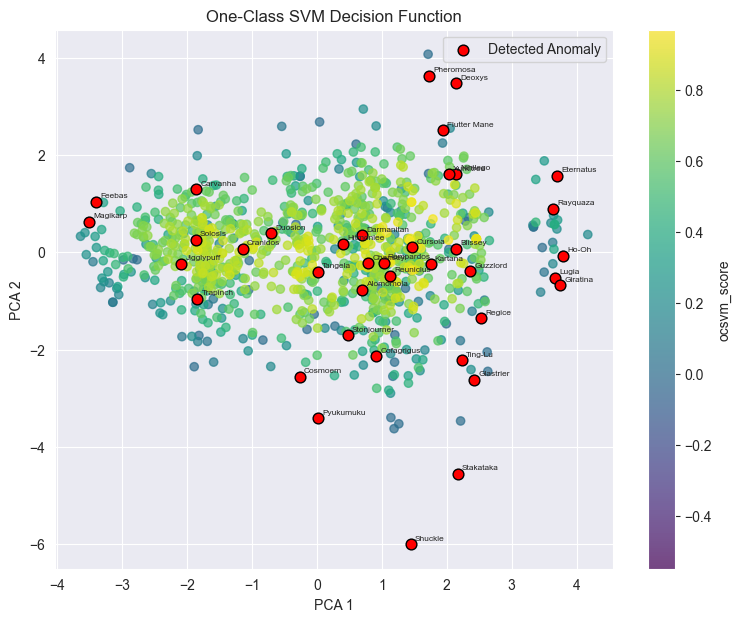

In [103]:
plot_decision_function_2d(
    score_column="ocsvm_score",
    title="One-Class SVM Decision Function",
    anomaly_flag_col="anomaly_ocsvm",
    annotate=True
)


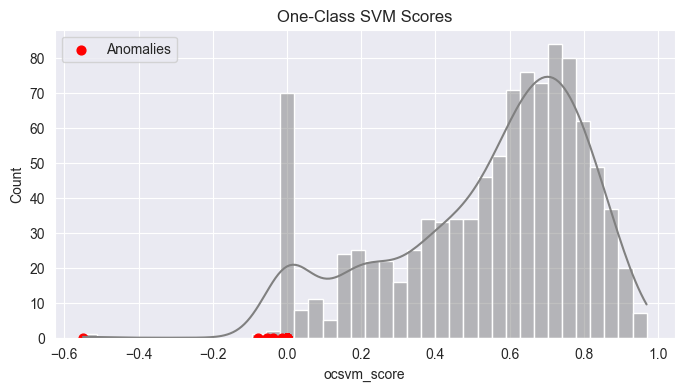

In [105]:
plot_score_with_anomalies("ocsvm_score", "anomaly_ocsvm", "One-Class SVM Scores")

## All classifiers in one ##


In [84]:
# Compute 2D PCA for visualization (independent of your PCA anomaly detector)
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

data_df["pca_vis_1"] = X_vis[:, 0]
data_df["pca_vis_2"] = X_vis[:, 1]


In [121]:
classif_cols = [
    "anomaly_if",
    "anomaly_lof",
    "anomaly_pca",
    "anomaly_ocsvm",
    "outliers_zscore",
    # "anomaly_strong"
]

# save fired anomalies from each method
data_df["anomaly_fired"] = data_df[classif_cols].sum(axis=1)
data_df["anomaly_any"] = data_df[classif_cols].any(axis=1)

# classified as an anomaly by at least N methods
classif_threshold = 3

data_df["anomaly_strong"] = data_df["anomaly_fired"] > classif_threshold

In [122]:
len(data_df[data_df["anomaly_strong"] == True])

11

In [146]:
data_df[data_df["anomaly_strong"] == True][["english_name", "gen"]]


,english_name,gen
112,Chansey,1.0
201,Wobbuffet,2.0
212,Shuckle,2.0
241,Blissey,2.0
248,Lugia,2.0
377,Regice,3.0
385,Deoxys,3.0
794,Pheromosa,7.0
797,Kartana,7.0
798,Guzzlord,7.0


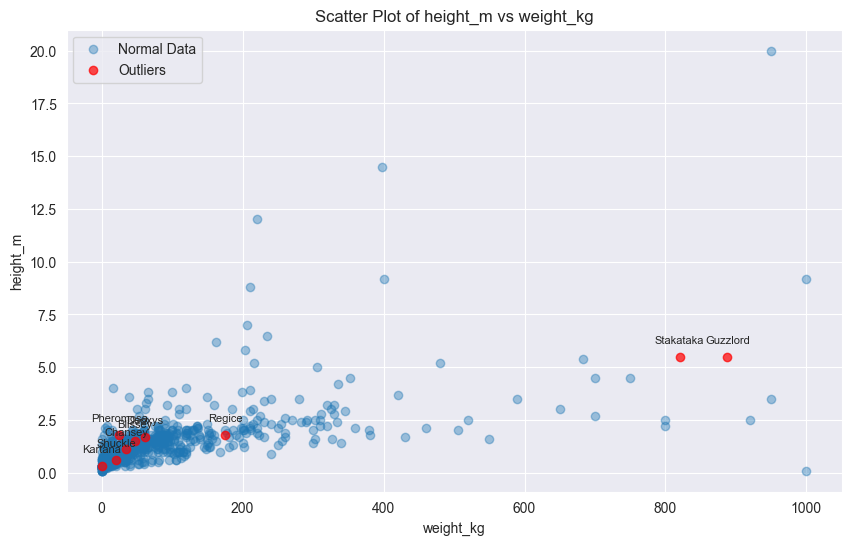

In [108]:
highlight_mask = data_df["anomaly_strong"]
scatter_with_outliers(data_df, 'weight_kg', 'height_m', highlight_mask, annotate=True)


# What features do outliers/anomalies differ in? #

## Which features show the strongest separation between anomaly and normal groups? ##

### U-test ###

For each feature, compare **mean, median, and variance**
Compute effect size - how big the difference is
"Effect" refers to how much an estimator or method is influenced by outliers or small deviations from ideal model assumptions

In [124]:
data_df[highlight_mask][["english_name"]]

,english_name
112,Chansey
212,Shuckle
241,Blissey
377,Regice
385,Deoxys
794,Pheromosa
797,Kartana
798,Guzzlord
804,Stakataka


In [109]:
import scipy.stats as stats

def compare_features(anomaly_flag="anomaly_strong"):
    rows = []
    anomalies = data_df[data_df[anomaly_flag]]
    normals = data_df[~data_df[anomaly_flag]]

    for col in num_cols:
        a = anomalies[col]
        n = normals[col]

        # Effect size
        d = (a.mean() - n.mean()) / np.sqrt((a.var() + n.var())/2)

        # Statistical test
        u_stat, p_val = stats.mannwhitneyu(a, n, alternative="two-sided")

        rows.append({
            "feature": col,
            "mean_anomaly": a.mean(),
            "mean_normal": n.mean(),
            "effect_size": d,
            "p_value": p_val
        })

    return pd.DataFrame(rows).sort_values("effect_size", ascending=False)


In [110]:
comparison_df = compare_features()
display(comparison_df.head(15))

,feature,mean_anomaly,mean_normal,effect_size,p_value
0,hp,118.777778,69.721182,0.708031,0.367661
4,sp_defense,104.666667,69.905419,0.643258,0.280248
2,defense,91.888889,72.345813,0.314289,0.912493
3,sp_attack,79.555556,69.962562,0.248142,0.524693
1,attack,86.111111,77.438424,0.164903,0.621428
5,speed,69.555556,67.167488,0.054982,0.680542


Outliers tend to have ....

### Isolation Forest ###
Using SHAP https://shap.readthedocs.io/en/latest/

shap values in the context of isolation forest score:


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


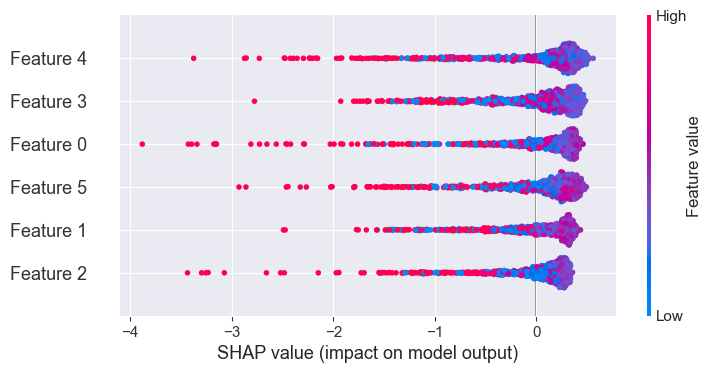

In [115]:
import shap
import tqdm as notebook_tqdm

explainer = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_scaled)

# shap.summary_plot(shap_values, X_scaled, feature_names=num_cols)
shap.plots.beeswarm(explainer(X_scaled))



### LOF ###


In [58]:
# lof.feature_importances_

### One-Class SVM ###


In [59]:
# ocsvm.feature_importances_

### PCA distances ###

Which original features have the largest loadings in PCs where anomalies are extreme?

In [116]:
loading_df = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))]
)

display(loading_df)


,PC1,PC2,PC3,PC4,PC5
hp,0.424115,-0.100078,0.262520,0.775930,-0.262196
attack,0.434404,-0.068767,0.642595,-0.196491,0.238226
defense,0.392494,-0.582627,-0.024532,-0.442629,0.080250
sp_attack,0.429337,0.364953,-0.393447,0.154819,0.704701
sp_defense,0.444025,-0.161433,-0.582931,-0.049214,-0.443193
speed,0.309645,0.697531,0.151469,-0.370152,-0.418377


In [117]:
loading_df["abs_PC1_loading"] = loading_df["PC1"].abs()
loading_df.sort_values("abs_PC1_loading", ascending=False).head(10)


,PC1,PC2,PC3,PC4,PC5,abs_PC1_loading
sp_defense,0.444025,-0.161433,-0.582931,-0.049214,-0.443193,0.444025
attack,0.434404,-0.068767,0.642595,-0.196491,0.238226,0.434404
sp_attack,0.429337,0.364953,-0.393447,0.154819,0.704701,0.429337
hp,0.424115,-0.100078,0.262520,0.775930,-0.262196,0.424115
defense,0.392494,-0.582627,-0.024532,-0.442629,0.080250,0.392494
speed,0.309645,0.697531,0.151469,-0.370152,-0.418377,0.309645


### Z-scores ###


In [118]:
outliers_zscores_df = data_df[
    (data_df["outliers_zscore"]) &
    (data_df["outlier_feature_list"].str.len() >= 1)
][["english_name", "outlier_feature_list"]]


In [119]:
outliers_zscores_df


,english_name,outlier_feature_list
90,Cloyster,[defense]
112,Chansey,[hp]
142,Snorlax,[hp]
201,Wobbuffet,[hp]
207,Steelix,[defense]
212,Shuckle,"[defense, sp_defense]"
241,Blissey,[hp]
248,Lugia,[sp_defense]
249,Ho-Oh,[sp_defense]
288,Slaking,[hp]


In [120]:
len(outliers_zscores_df)


31

# Distribution of anomalies/outliers across generations #

In [127]:
anomaly_flag = "anomaly_strong"

gen_counts = data_df.groupby("gen")[anomaly_flag].sum()
gen_total = data_df.groupby("gen").size()

anomaly_rate = (gen_counts / gen_total).rename("anomaly_rate")

distribution_df = pd.concat(
    [
        gen_total.rename("total"),
        gen_counts.rename("anomalies"),
        anomaly_rate
    ],
    axis=1
)

In [128]:
distribution_df


,total,anomalies,anomaly_rate
gen,,,
1.0,151,1,0.006623
2.0,100,4,0.040000
3.0,135,2,0.014815
4.0,107,0,0.000000
5.0,156,0,0.000000
6.0,72,0,0.000000
7.0,88,4,0.045455
8.0,95,0,0.000000
9.0,120,0,0.000000


/var/folders/8y/0_xr6dfx6gq8z24st9njsbpm0000gn/T/ipykernel_4978/4090103192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_df.index, y=distribution_df["anomalies"], palette="viridis")


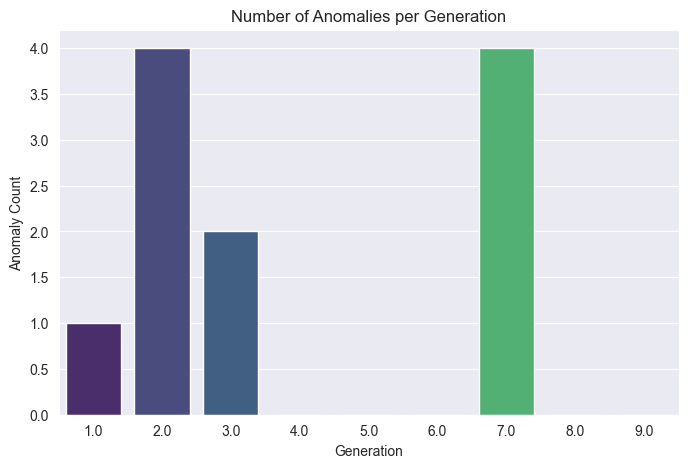

In [129]:
# Plot anomaly distribution by generation

plt.figure(figsize=(8,5))
sns.barplot(x=distribution_df.index, y=distribution_df["anomalies"], palette="viridis")
plt.title("Number of Anomalies per Generation")
plt.xlabel("Generation")
plt.ylabel("Anomaly Count")
plt.grid(True, axis='y')
plt.show()

/var/folders/8y/0_xr6dfx6gq8z24st9njsbpm0000gn/T/ipykernel_4978/2951354643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_df.index, y=distribution_df["anomaly_rate"], palette="coolwarm")


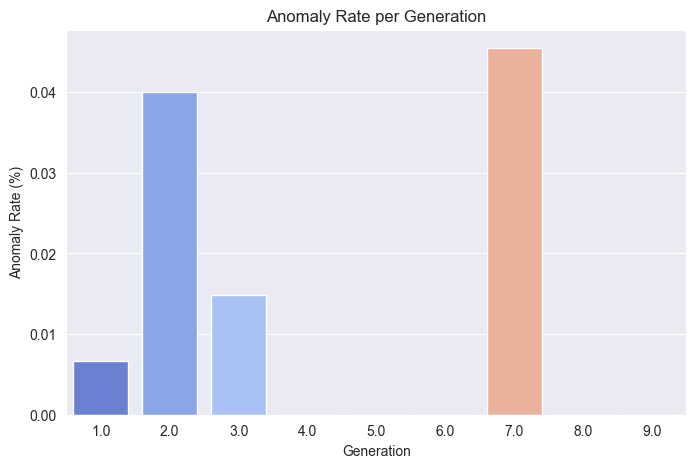

In [130]:
# plot of rates

plt.figure(figsize=(8,5))
sns.barplot(x=distribution_df.index, y=distribution_df["anomaly_rate"], palette="coolwarm")
plt.title("Anomaly Rate per Generation")
plt.xlabel("Generation")
plt.ylabel("Anomaly Rate (%)")
plt.grid(True, axis='y')
plt.show()


The generatoin with most outliers/anomalies is no. 8

Spearman rank correlation - check whether anomaly rate increases with generation number

Spearman's correlation determines the strength and direction of the monotonic relationship (A monotonic relationship is a relationship that does one of the following: (1) as the value of one variable increases, so does the value of the other variable; or (2) as the value of one variable increases, the other variable value decreases) between your two variables rather than the strength and direction of the linear relationship between your two variables, which is what Pearson's correlation determines. https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php

Assumptions:
* two variables that are either ordinal, interval, or ratio

In [131]:
from scipy.stats import spearmanr

In [132]:
corr, pval = spearmanr(distribution_df.index, distribution_df["anomaly_rate"])
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.4f}")


Spearman correlation: -0.420, p-value: 0.2605


Weak / no trend

Are anomaly rates significantly different across generations?

Chi-square test of indepence


In [134]:
# build contingency table
contingency = pd.DataFrame({
    "anomaly": gen_counts,
    "normal": gen_total - gen_counts
})

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square p-value: {p:.4f}")


Chi-square p-value: 0.0019


===> Generations have significant differences in anomaly frequency

Comparing detectors across generatoins to see
* which methods agree
* which generations appear more anomalous (consistently)
* whether a certain generation stands out

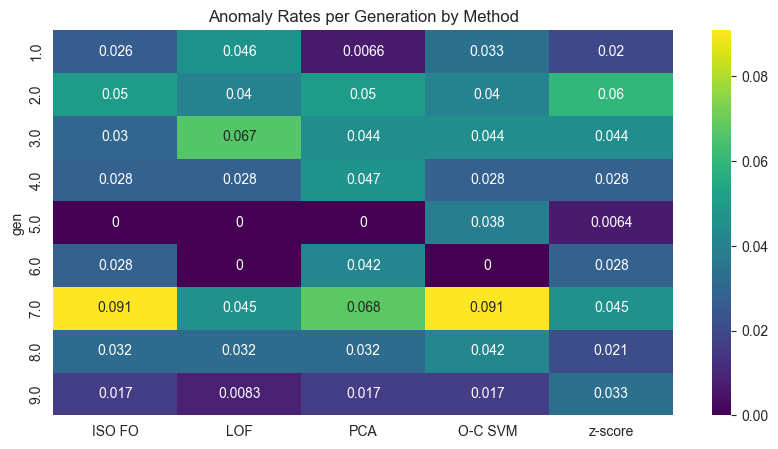

In [135]:
classif_cols = [
    "anomaly_if",
    "anomaly_lof",
    "anomaly_pca",
    "anomaly_ocsvm",
    "outliers_zscore",
    # "anomaly_strong"
]

col_labels = {
    "anomaly_if": "ISO FO",
    "anomaly_lof": "LOF",
    "anomaly_pca": "PCA",
    "anomaly_ocsvm": "O-C SVM",
    "outliers_zscore": "z-score"
}

heatmap_data = {
    col_labels[m]: data_df.groupby("gen")[m].mean()
    for m in classif_cols
}

heatmap_df = pd.DataFrame(heatmap_data)

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_df, annot=True, cmap="viridis")
plt.title("Anomaly Rates per Generation by Method")
plt.show()
